In [41]:
#The purpose of this notebook is to optimize and XGBoost regressor on each of the 4 different feature sets, Peng, Ghorbani, Xiong and CHALPHAD.
#major change, Since all features are possible to calculate except for Ghorbani, Ghorbani alloys will be used and features calcuated for all 4 feature sets, and then the best model will be selected based on the performance on the Ghorbani alloys.


In [73]:
#import necessary libraries
#import the required libraries
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
import re
from sklearn.model_selection import RepeatedKFold,ShuffleSplit
from CBFV import composition
from scipy.stats import sem
import warnings
import ujson as js
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from ax.api.client import Client
from ax.api.configs import RangeParameterConfig, ChoiceParameterConfig
import matplotlib.pyplot as plt

In [43]:
#Take formula column and parse it into a dataframe of element columns with atomic percentages as values. This function should be able to handle the complex formulas in the Ghorbani dataset, including nested parentheses, brackets, and braces, as well as fractions and equal splits.
def assemble_composition_df(df, formula_column):
    element_list = [
        "Ag", "Al", "Am", "As", "Au",
        "B", "Ba", "Be", "Bi",
        "C", "Ca", "Cd", "Ce", "Co", "Cr", "Cs", "Cu",
        "Dy",
        "Er", "Eu",
        "Fe",
        "Ga", "Gd", "Ge",
        "H", "Hf", "Hg", "Ho",
        "In", "Ir",
        "K",
        "La", "Li", "Lu",
        "Mg", "Mn", "Mo",
        "N", "Na", "Nb", "Nd", "Ni", "Np",
        "O", "Os",
        "P", "Pa", "Pb", "Pd", "Pr", "Pt", "Pu",
        "Rb", "Re", "Rh", "Ru",
        "S", "Sb", "Sc", "Se", "Si", "Sm", "Sn", "Sr",
        "Ta", "Tb", "Tc", "Te", "Th", "Ti", "Tl", "Tm",
        "U",
        "V",
        "W",
        "Y", "Yb",
        "Zn", "Zr"
    ]
    
    def parse_fraction(s):
        """Parse a string that might be a fraction (e.g., '5/6') or a number."""
        if '/' in s:
            num, denom = s.split('/')
            return float(num) / float(denom)
        return float(s)
    
    def parse_element_composition(formula_str):
        """
        Parse element-number pairs from a formula string.
        Returns a dict of {element: amount}
        """
        composition = {}
        # Pattern to match element followed by optional number (including fractions)
        pattern = r'([A-Z][a-z]?)(\d+(?:\.\d+)?(?:/\d+(?:\.\d+)?)?)?'
        
        matches = re.findall(pattern, formula_str)
        for element, amount in matches:
            if element and element in element_list:
                if amount:
                    val = parse_fraction(amount)
                else:
                    val = 1.0
                composition[element] = composition.get(element, 0) + val
        
        return composition
    
    def parse_formula(formula):
        """
        Parse a complete alloy formula handling nested brackets, parentheses, and braces.
        Returns a dict of {element: atomic_percent}
        """
        composition = {}
        
        # Remove citation references like [24], [30], etc. at the end
        formula = re.sub(r'\[\d+\]$', '', formula)
        formula = re.sub(r'\[\d+\]', '', formula)
        
        # Remove spaces and commas used as separators
        formula = formula.replace(' ', '').replace(',', '')
        
        def process_innermost_group(f):
            """Find and process the innermost bracketed group."""
            pattern = r'([\(\[\{])([^\(\)\[\]\{\}]+)([\)\]\}])(\d+(?:\.\d+)?)?'
            
            match = re.search(pattern, f)
            if not match:
                return f, False
            
            open_bracket, content, close_bracket, multiplier = match.groups()
            
            # Parse the content of the group
            inner_comp = parse_element_composition(content)
            
            # Calculate the sum of inner compositions
            inner_sum = sum(inner_comp.values())
            
            # Determine the multiplier
            if multiplier:
                mult = float(multiplier)
            else:
                mult = 1.0
            
            # Determine if inner values are fractions or percentages
            # If sum is close to 1, treat as fractions; if close to 100, treat as percentages
            if inner_sum > 1.5:  # Likely percentages within the group
                # Normalize to fractions, then multiply
                inner_comp = {k: v / inner_sum for k, v in inner_comp.items()}
            
            # Apply multiplier
            expanded = {elem: amt * mult for elem, amt in inner_comp.items()}
            
            # Create replacement string
            replacement_parts = []
            for elem, amt in expanded.items():
                replacement_parts.append(f"{elem}{amt}")
            replacement = ''.join(replacement_parts)
            
            new_f = f[:match.start()] + replacement + f[match.end():]
            
            return new_f, True
        
        # Iteratively process innermost groups until none remain
        processed_formula = formula
        max_iterations = 20
        iteration = 0
        
        while iteration < max_iterations:
            processed_formula, found = process_innermost_group(processed_formula)
            if not found:
                break
            iteration += 1
        
        # Now parse the final expanded formula
        composition = parse_element_composition(processed_formula)
        
        # Handle equal split case (elements with no numbers)
        total = sum(composition.values())
        num_elements = len(composition)
        
        # Check if all elements have value 1.0 (no numbers given)
        if num_elements > 0 and all(v == 1.0 for v in composition.values()):
            equal_share = 100.0 / num_elements
            composition = {k: equal_share for k in composition}
        # If total is very small (< 2), scale up to 100
        elif total > 0 and total < 2:
            scale = 100.0 / total
            composition = {k: v * scale for k, v in composition.items()}
        
        return composition
    
    # Process all formulas
    composition_dicts = []
    for formula in df[formula_column]:
        try:
            comp = parse_formula(str(formula))
            composition_dicts.append(comp)
        except Exception as e:
            print(f"Error parsing '{formula}': {e}")
            composition_dicts.append({})
    
    # Create DataFrame with element columns
    comp_df = pd.DataFrame(composition_dicts)
    
    # Ensure all element columns exist, fill missing with 0
    for elem in element_list:
        if elem not in comp_df.columns:
            comp_df[elem] = 0.0
    
    # Reorder columns to match element_list and fill NaN with 0
    comp_df = comp_df.reindex(columns=element_list, fill_value=0.0)
    comp_df = comp_df.fillna(0.0)
    
    return comp_df

#take composition df and produce composition strings
def canonical_comp_string(df, tol=1e-9, decimals=2):
    element_cols = sorted([c for c in df.columns if c != "Composition String"])
    out = []
    for _, row in df[element_cols].iterrows():
        vals = row.astype(float).fillna(0.0).to_numpy()
        vals[vals < tol] = 0.0
        s = vals.sum()
        if s <= 0:
            out.append("")
            continue
        vals = vals / s * 100.0
        vals = np.round(vals, decimals)
        parts = [f"{el}{v:.{decimals}f}" for el, v in zip(element_cols, vals) if v > 0]
        out.append("".join(parts))
    return out

#create function that takes a composition df and gets the index of rows who sum to greater than 100. This is to catch any errors in the composition parsing where the percentages add up to more than 100.
def find_rows_sum_greater_than_100(df):
    over_100_index = df.sum(axis=1) > 100
    return over_100_index



In [44]:
#load and process the Ghorbani dataset 
raw_Ghorbani_df = pd.read_excel(r"Data\Paper Data\Ghorbani, 2022.xlsx")

#Convert the alloys in Ghorbani dataset into cananical composition strings
Ghorbani_composition_df = assemble_composition_df(raw_Ghorbani_df, "Alloy")
Ghorbani_canonical_strings = canonical_comp_string(Ghorbani_composition_df)

#save the original length of the Ghorbani dataset for later comparison after dropping rows that sum to greater than 100
original_Ghorbani_length = len(raw_Ghorbani_df)
print(f"Original length of Ghorbani dataset: {original_Ghorbani_length}")

#replace the Ghorbani alloy column with the canonical composition strings and rename as composition string
raw_Ghorbani_df["Composition String"] = Ghorbani_canonical_strings
raw_Ghorbani_df = raw_Ghorbani_df.drop(columns=["Alloy"])


#get the index of any rows in the composition df that sum to greater than 100
Ghorbani_over_100_index = find_rows_sum_greater_than_100(Ghorbani_composition_df)
print(f"Number of rows in Ghorbani composition df that sum to greater than 100: {Ghorbani_over_100_index.sum()}")

#drop the rows over 100 from the composition df and the original df
raw_Ghorbani_df = raw_Ghorbani_df[~Ghorbani_over_100_index].reset_index(drop=True)
Ghorbani_composition_df = Ghorbani_composition_df[~Ghorbani_over_100_index].reset_index(drop=True)

#Check for any duplicate composition strings in the Ghorbani dataset and replace with the mean of the duplicates
raw_Ghorbani_df = raw_Ghorbani_df.groupby("Composition String").mean().reset_index()
Ghorbani_composition_df['Composition String'] = raw_Ghorbani_df['Composition String']
Ghorbani_composition_df = Ghorbani_composition_df.groupby("Composition String").mean().reset_index()

#calculate the post processing length of the Ghorbani dataset and print the number of rows dropped
post_processing_Ghorbani_length = len(raw_Ghorbani_df)

#cacluate the number of duplicate rows in the Ghorbani dataset and print
ghorbani_duplicate_count = original_Ghorbani_length - post_processing_Ghorbani_length - Ghorbani_over_100_index.sum()
print(f"Number of duplicate rows in Ghorbani dataset that were averaged: {ghorbani_duplicate_count}")
print(f"Number of rows dropped from Ghorbani dataset after processing: {original_Ghorbani_length - post_processing_Ghorbani_length}")

#create a set of the Ghorbani composition strings for later comparison with the other datasets
Ghorbani_canonical_strings = raw_Ghorbani_df["Composition String"].tolist()

#split the Ghorbani dataset into X data
Ghorbani_X = raw_Ghorbani_df.drop(columns=["No.", "Tg", "Tx", "Tl"])

#print the final length of the Ghorbani dataset after processing
print(f"Final length of Ghorbani dataset after processing: {len(raw_Ghorbani_df)}")

Original length of Ghorbani dataset: 715
Number of rows in Ghorbani composition df that sum to greater than 100: 26
Number of duplicate rows in Ghorbani dataset that were averaged: 28
Number of rows dropped from Ghorbani dataset after processing: 54
Final length of Ghorbani dataset after processing: 661


In [45]:
#find the interseciton of Xiong and Ghorbani composition strings, only use these for the rest of the analysis to ensure a fair comparison between the two datasets. This is because the Ghorbani dataset is the smallest and we want to make sure we are comparing the same alloys across all datasets.
raw_xiong_df = pd.read_excel(r"Data\Paper Data\XIONG 2021.xlsx")

xiong_comp_df = assemble_composition_df(raw_xiong_df, "Alloys")

xiong_can_strings = canonical_comp_string(xiong_comp_df)

print(len(xiong_can_strings))
print(len(Ghorbani_canonical_strings))

# Find strings in Ghorbani_canonical_strings that are not in xiong_can_strings
ghorbani_not_in_xiong = set(Ghorbani_canonical_strings) - set(xiong_can_strings)
print(f"\n{len(ghorbani_not_in_xiong)} strings in Ghorbani_canonical_strings not in xiong_can_strings:")

    
#find the intersection of the two sets
intersection = set(Ghorbani_canonical_strings).intersection(set(xiong_can_strings))
print(f"\nNumber of composition strings in the intersection of Ghorbani and Xiong datasets: {len(intersection)}")

#filter the Ghorbani, X canonical strings, and composition df to only include the intersection
Ghorbani_X = Ghorbani_X[Ghorbani_X["Composition String"].isin(intersection)].reset_index(drop=True)
Ghorbani_canonical_strings = Ghorbani_X["Composition String"].tolist()
Ghorbani_composition_df = Ghorbani_composition_df[Ghorbani_composition_df["Composition String"].isin(intersection)].reset_index(drop=True)


695
661

204 strings in Ghorbani_canonical_strings not in xiong_can_strings:

Number of composition strings in the intersection of Ghorbani and Xiong datasets: 457


In [46]:
#Peng uses a basic compositional input, convert the ghorbani composition strings into a composition df and use this to make Peng dataframe 
#peng composition df is made by taking a copy of the Ghorbani composition df
Peng_composition_df = Ghorbani_composition_df.copy()
Peng_canonical_strings = Ghorbani_canonical_strings.copy()

#print the length of the Peng composition df and the length of peng_canonical_strings 
print(f"Length of Peng composition df: {len(Peng_composition_df)}")
print(f"Length of Peng canonical strings: {len(Peng_canonical_strings)}")

#processing already occured so just checking that nothing is amiss with the Peng composition df and canonical strings before using them to create the Peng dataset
#Check for any rows in the Peng composition df that sum to greater than 100 and print
Peng_over_100_index = find_rows_sum_greater_than_100(Peng_composition_df.drop(columns=["Composition String"]))
print(f"Number of rows in Peng composition df that sum to greater than 100: {Peng_over_100_index.sum()}")

#find duplicates in the Peng composition df and print the number of duplicates
Peng_duplicates = Peng_composition_df.duplicated(subset=["Composition String"], keep=False)
print(f"Number of duplicate rows in Peng composition df: {Peng_duplicates.sum()}")

#normalize the Peng composition df so that all rows sum to 1
Peng_composition_df = Peng_composition_df.drop(columns=["Composition String"])
Peng_composition_df = Peng_composition_df.div(100, axis=0)

#drop columns with all zeros from the Peng composition df
pre_column_drop_length = len(Peng_composition_df.columns)
Peng_composition_df = Peng_composition_df.loc[:, (Peng_composition_df != 0).any(axis=0)]
post_column_drop_length = len(Peng_composition_df.columns)
print(f"Dropped {pre_column_drop_length - post_column_drop_length} columns with all zeros from Peng composition df")

#print the length of the Peng composition df and the number of unique composition strings in the Peng canonical strings to check for duplicates
print(f"Length of Peng composition df: {len(Peng_composition_df)}")

#create the peng x data
Peng_x = Peng_composition_df.copy()
Peng_x["Composition String"] = Peng_canonical_strings

Length of Peng composition df: 457
Length of Peng canonical strings: 457
Number of rows in Peng composition df that sum to greater than 100: 0
Number of duplicate rows in Peng composition df: 0
Dropped 40 columns with all zeros from Peng composition df
Length of Peng composition df: 457


In [47]:
#define function to compute xiong features from a composition dataframe and an elemental property dataframe. This function should be able to handle missing values in the elemental property dataframe by either dropping those elements or filling with NaN, depending on the missing_policy parameter. It should also have an option to compute features using only nonzero constituents or all constituents, controlled by the use_nonzero_only parameter. The function should return a new dataframe with the computed features for each alloy.
def compute_xiong_features(
    alloy_df,
    elem_info_df,
    element_col="Element",
    radius_col="Rm (nm)",
    missing_policy="warn",
    use_nonzero_only=True,
    verbose=False,
):
    """
    Compute Xiong-style alloy descriptors from a composition DataFrame and
    an elemental-property DataFrame.

    Assumes alloy_df already contains normalized atomic fractions:
        - each row is one alloy
        - columns are element symbols
        - row sums should be ~1
    """

    # 1. Clean and align
    ei = elem_info_df.copy()
    ei.columns = ei.columns.astype(str).str.strip()
    ei[element_col] = ei[element_col].astype(str).str.strip()
    ei = ei.set_index(element_col)

    alloy_df = alloy_df.copy()
    alloy_df.columns = alloy_df.columns.astype(str).str.strip()

    alloy_elements = set(alloy_df.columns)
    known_elements = set(ei.index)
    missing = sorted(alloy_elements - known_elements)

    if missing:
        if missing_policy == "error":
            raise ValueError(
                f"Elements in alloy_df not found in elem_info_df: {missing}"
            )
        elif missing_policy == "warn":
            warnings.warn(
                f"Elements in alloy_df not found in elem_info_df (dropped): {missing}"
            )
        elif missing_policy != "drop":
            raise ValueError("missing_policy must be 'warn', 'drop', or 'error'")

    common_elements = sorted(alloy_elements & known_elements)
    if not common_elements:
        raise ValueError("No overlapping elements between alloy_df and elem_info_df.")

    A = alloy_df[common_elements].copy().fillna(0.0)
    A = A.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    row_sums = A.sum(axis=1)
    zero_rows = row_sums <= 0
    if zero_rows.any():
        raise ValueError(
            f"{int(zero_rows.sum())} alloy row(s) sum to 0; cannot compute features."
        )

    P = ei.loc[common_elements].copy()
    P = P.apply(pd.to_numeric, errors="coerce")

    A_mat = A.to_numpy(dtype=np.float64)
    P_mat = P.to_numpy(dtype=np.float64)
    prop_names = P.columns.tolist()

    n_alloys, n_elems = A_mat.shape
    n_props = P_mat.shape[1]

    if verbose:
        print(f"Elements matched: {len(common_elements)}  |  Dropped: {len(missing)}")

    constituent_mask = A_mat > 0 if use_nonzero_only else np.ones_like(A_mat, dtype=bool)

    x1 = np.full((n_alloys, n_props), np.nan, dtype=np.float64)
    x2 = np.full((n_alloys, n_props), np.nan, dtype=np.float64)
    xD = np.full((n_alloys, n_props), np.nan, dtype=np.float64)
    xd = np.full((n_alloys, n_props), np.nan, dtype=np.float64)

    # 2. Compute descriptors property-by-property
    for j in range(n_props):
        prop_vals = P_mat[:, j]
        prop_2d = np.broadcast_to(prop_vals, (n_alloys, n_elems))

        active = constituent_mask
        finite_prop = np.isfinite(prop_2d)

        # x1 = sum(a_i * x_i) / sum(a_i over valid constituents)
        x1_weights = np.where(active & finite_prop, A_mat, 0.0)
        x1_terms = np.where(active & finite_prop, A_mat * prop_2d, 0.0)
        x1_den = x1_weights.sum(axis=1)
        x1[:, j] = np.where(x1_den > 0, x1_terms.sum(axis=1) / x1_den, np.nan)

        # x2 = (sum(a_i / x_i))^-1 ; NaN if any constituent has x_i == 0 or NaN
        bad_x2 = active & ((~finite_prop) | (prop_2d == 0))
        any_bad_x2 = bad_x2.any(axis=1)

        good_x2 = active & finite_prop & (prop_2d != 0)
        with np.errstate(divide="ignore", invalid="ignore"):
            sum_a_over_x = np.where(good_x2, A_mat / prop_2d, 0.0).sum(axis=1)

        x2[:, j] = np.where(
            (~any_bad_x2) & np.isfinite(sum_a_over_x) & (sum_a_over_x != 0),
            1.0 / sum_a_over_x,
            np.nan,
        )

        # xD = sqrt(sum(a_i * (x_i - x1)^2))
        bad_xD = active & (~finite_prop)
        any_bad_xD = bad_xD.any(axis=1)

        diff_sq = (prop_2d - x1[:, [j]]) ** 2
        diff_sq = np.where(active & finite_prop, diff_sq, 0.0)
        xD_val = np.sqrt((A_mat * diff_sq).sum(axis=1))
        xD[:, j] = np.where(~any_bad_xD & np.isfinite(x1[:, j]), xD_val, np.nan)

        # xd = sqrt(sum(a_i * (1 - x_i/x1)^2))
        x1j = x1[:, j]
        x1_safe = np.where((x1j == 0) | (~np.isfinite(x1j)), np.nan, x1j)

        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = prop_2d / x1_safe[:, None]

        rel_diff_sq = (1.0 - ratio) ** 2
        rel_diff_sq = np.where(np.isfinite(rel_diff_sq) & active & finite_prop, rel_diff_sq, 0.0)

        bad_xd = active & (~finite_prop)
        any_bad_xd = bad_xd.any(axis=1)

        xd_val = np.sqrt((A_mat * rel_diff_sq).sum(axis=1))
        xd[:, j] = np.where(
            (~any_bad_xd) & np.isfinite(x1j) & (x1j != 0),
            xd_val,
            np.nan,
        )

    # 3. Assemble results
    results = {}
    for j, prop in enumerate(prop_names):
        prop = str(prop).strip()
        results[f"{prop}_x1"] = x1[:, j]
        results[f"{prop}_x2"] = x2[:, j]
        results[f"{prop}_xD"] = xD[:, j]
        results[f"{prop}_xd"] = xd[:, j]

    # 4. Delta
    if radius_col is not None:
        radius_col = str(radius_col).strip()
        if radius_col in prop_names:
            r_idx = prop_names.index(radius_col)
            r_vals = P_mat[:, r_idx]
            r_2d = np.broadcast_to(r_vals, (n_alloys, n_elems))
            finite_r = np.isfinite(r_2d)
            active = constituent_mask

            r_weights = np.where(active & finite_r, A_mat, 0.0)
            r_terms = np.where(active & finite_r, A_mat * r_2d, 0.0)
            r_den = r_weights.sum(axis=1)
            r_bar = np.where(r_den > 0, r_terms.sum(axis=1) / r_den, np.nan)
            results["r_bar"] = r_bar

            bad_delta = active & (~finite_r)
            any_bad_delta = bad_delta.any(axis=1)

            r_bar_safe = np.where((r_bar == 0) | (~np.isfinite(r_bar)), np.nan, r_bar)
            with np.errstate(divide="ignore", invalid="ignore"):
                r_ratio = r_2d / r_bar_safe[:, None]

            delta_term = (1.0 - r_ratio) ** 2
            delta_term = np.where(np.isfinite(delta_term) & active & finite_r, delta_term, 0.0)

            delta = np.sqrt((A_mat * delta_term).sum(axis=1))
            delta = np.where(
                (~any_bad_delta) & np.isfinite(r_bar) & (r_bar != 0),
                delta,
                np.nan,
            )
            results["delta"] = delta
        else:
            warnings.warn(
                f"radius_col='{radius_col}' not found in elem_info_df. Skipping delta computation."
            )

    xiong_features_df = pd.DataFrame(results, index=alloy_df.index)

    if verbose:
        nan_counts = xiong_features_df.isna().sum()
        cols_with_nan = nan_counts[nan_counts > 0]
        if len(cols_with_nan):
            print(f"Features with NaNs ({len(cols_with_nan)}):")
            print(cols_with_nan.to_string())
        else:
            print("No NaN values in output.")

    return xiong_features_df

In [48]:
#load both Xiong datasets
Xiong_element_info_df = pd.read_excel(r"Data\Paper Data\Xiong element data.xlsx")
Xiong_raw_df = pd.read_excel(r"Data\Paper Data\XIONG 2021.xlsx")

#Create a Xiong composition df and canonical composition strings using the same functions as for the Ghorbani dataset. This is to ensure that the same parsing and processing is applied to both datasets for a fair comparison. The Xiong composition df will be used to compute the Xiong features and the canonical composition strings will be added to the original Xiong dataframe for later comparison with the other datasets.
Xiong_raw_composition_df = assemble_composition_df(Xiong_raw_df, "Alloys")
Xiong_raw_canonical_strings = canonical_comp_string(Xiong_raw_composition_df)
Xiong_raw_df["Composition String"] = Xiong_raw_canonical_strings
Xiong_raw_df = Xiong_raw_df.drop(columns=["Alloys"])

#filter the Xiong_raw_df to only include Ghorbani composition strings for a fair comparison between the two datasets. This is because the Ghorbani dataset is the smaller of the two and we want to make sure we are comparing the same alloys across all datasets.
Xiong_raw_df = Xiong_raw_df[Xiong_raw_df["Composition String"].isin(Ghorbani_canonical_strings)].reset_index(drop=True)
Xiong_raw_canonical_strings = Xiong_raw_df["Composition String"].tolist()

#print the length of the Xiong_raw_df and the number of unique composition strings in the Xiong_raw_canonical_strings to check for duplicates
print(f"Length of Xiong_raw_df: {len(Xiong_raw_df)}")
print(f"Number of unique composition strings in Xiong_raw_canonical_strings: {len(set(Xiong_raw_df['Composition String']))}")

#normalized the composition df so that all rows sum to 1
Xiong_composition_df = Xiong_raw_composition_df.copy()
Xiong_composition_df = Xiong_composition_df.div(100, axis=0)

#drop the columns with all 0s in the normalized composition df
xiong_pre_column_drop = len(Xiong_composition_df.columns)
Xiong_composition_df = Xiong_composition_df.loc[:, (Xiong_composition_df != 0).any(axis=0)]
xiong_post_column_drop = len(Xiong_composition_df.columns)
print(f"Dropped {xiong_pre_column_drop - xiong_post_column_drop} columns with all zeros from Xiong normalized composition df")


#find the index of rows in the Xiong composition df that sum to greater than 100 and drop from both composition df and original df
Xiong_over_100_index = find_rows_sum_greater_than_100(Xiong_composition_df)
print(f"Number of rows in Xiong composition df that sum to greater than 100: {Xiong_over_100_index.sum()}")


# ── Compute Xiong features ─────────────────────────────────────────────────
xiong_features_df = compute_xiong_features(
    alloy_df=Xiong_composition_df,
    elem_info_df=Xiong_element_info_df,
    element_col="Element",
    radius_col="Rm (nm)",       # already in fractions
    missing_policy="warn",
    use_nonzero_only=True,      # only constituent elements per alloy
    verbose=True,
)

print(f"\nShape: {xiong_features_df.shape}")

#drop the less useful features from the Xiong dataset to reduce the feature space and prevent overfitting likely what Xiong did in their original feature engineering
xiong_features_df = xiong_features_df.drop(columns=["sVEC_x2", "pVEC_x2", "pVEC_xd", "dVEC_x2"])


#add the entropy and enthalpy of mixing features to the Xiong features df
xiong_features_df['Hmix (kJ/mol)'] = Xiong_raw_df['Hmix (kJ/mol)']
xiong_features_df['Smix (J/K/mol)'] = Xiong_raw_df['Smix (J/K/mol)']

#add the canonical strings from the original df to the Xiong features df for later comparison with the other datasets
xiong_features_df['Composition String'] = Xiong_raw_df['Composition String']

#check the Xiong_features_df for duplicates using the composition string and drop any duplicates by averaging the features of the duplicates
xiong_features_df = xiong_features_df.groupby("Composition String").mean().reset_index()

#length of the Xiong dataset after processing
post_processing_Xiong_length = len(xiong_features_df)

#print the number of duplicate rows in the Xiong dataset that were averaged and the number of rows dropped from the Xiong dataset after processing
print(f"Number of rows in Xiong dataset after processing: {post_processing_Xiong_length}")

Xiong_X = xiong_features_df.copy()

Length of Xiong_raw_df: 460
Number of unique composition strings in Xiong_raw_canonical_strings: 457
Dropped 34 columns with all zeros from Xiong normalized composition df
Number of rows in Xiong composition df that sum to greater than 100: 0
Elements matched: 45  |  Dropped: 0
Features with NaNs (5):
sVEC_x2     30
pVEC_x2    695
pVEC_xd    232
dVEC_x2    635
dVEC_xd      1

Shape: (695, 94)
Number of rows in Xiong dataset after processing: 457


C:\Users\Chris\AppData\Local\Temp\ipykernel_568\738415743.py:104: RuntimeWarning:

divide by zero encountered in divide



In [49]:
#Create canoncial string sets for each dataset to find the intersections and unique compositions between the datasets
Xiong_composition_strings_set = set(xiong_features_df["Composition String"])
Peng_composition_strings_set = set(Peng_x["Composition String"])
Ghorbani_composition_strings_set = set(raw_Ghorbani_df["Composition String"])

#find the intersecting compositions
intersection_compositions = Xiong_composition_strings_set & Peng_composition_strings_set & Ghorbani_composition_strings_set
print(f"Number of intersecting compositions between all three datasets: {len(intersection_compositions)}")

#filter the datasets to only include the intersecting compositions for later comparison of model performance on the same compositions
Xiong_X_intersection = Xiong_X[Xiong_X["Composition String"].isin(intersection_compositions)].reset_index(drop=True)
Peng_X_intersection = Peng_x[Peng_x["Composition String"].isin(intersection_compositions)].reset_index(drop=True)
Ghorbani_X_intersection = Ghorbani_X[Ghorbani_X["Composition String"].isin(intersection_compositions)].reset_index(drop=True)

#print(raw_Ghorbani_df.columns)
#pull the y_data for the intersecting compositions from the Ghorbani dataset
y_data = raw_Ghorbani_df[raw_Ghorbani_df["Composition String"].isin(intersection_compositions)][['Composition String', 'Y (Dmax)']].reset_index(drop=True)



#check the length of all data to ensure they match
print(f"Length of Xiong intersection data: {len(Xiong_X_intersection)}")
print(f"Length of Peng intersection data: {len(Peng_X_intersection)}")
print(f"Length of Ghorbani intersection data: {len(Ghorbani_X_intersection)}")
print(f"Length of y data: {len(y_data)}")

Number of intersecting compositions between all three datasets: 457
Length of Xiong intersection data: 457
Length of Peng intersection data: 457
Length of Ghorbani intersection data: 457
Length of y data: 457


In [50]:
#split into train_opt and test sets using a 80/20 split and a fixed random state for reproducibility
train_opt_compositions, test_compositions = train_test_split(
    list(intersection_compositions), test_size=0.2, random_state=42)

#separate the train_opt and test sets for each dataset using the composition strings
Xiong_X_train_opt = Xiong_X_intersection[Xiong_X_intersection["Composition String"].isin(train_opt_compositions)].reset_index(drop=True)
Xiong_X_test = Xiong_X_intersection[Xiong_X_intersection["Composition String"].isin(test_compositions)].reset_index(drop=True)

Peng_X_train_opt = Peng_X_intersection[Peng_X_intersection["Composition String"].isin(train_opt_compositions)].reset_index(drop=True)
Peng_X_test = Peng_X_intersection[Peng_X_intersection["Composition String"].isin(test_compositions)].reset_index(drop=True)

Ghorbani_X_train_opt = Ghorbani_X_intersection[Ghorbani_X_intersection["Composition String"].isin(train_opt_compositions)].reset_index(drop=True)
Ghorbani_X_test = Ghorbani_X_intersection[Ghorbani_X_intersection["Composition String"].isin(test_compositions)].reset_index(drop=True)

y_train_opt = y_data[y_data["Composition String"].isin(train_opt_compositions)].reset_index(drop=True)
y_test = y_data[y_data["Composition String"].isin(test_compositions)].reset_index(drop=True)

In [51]:
#create a dataframe with the composition string and a false target varibale for CBFV featurization of the intersecting compositions
cbfv_train_opt_intersection_df = pd.DataFrame({"formula": list(train_opt_compositions), "target": [0]*len(train_opt_compositions)})
cbfv_test_intersection_df = pd.DataFrame({"formula": list(test_compositions), "target": [0]*len(test_compositions)})

#featurize the intersecting compositions using CBFV and drop the target variable
train_opt_cbfv, _, _, skipped = composition.generate_features(cbfv_train_opt_intersection_df, elem_prop="magpie", drop_duplicates=False)
test_cbfv, _, _, skipped_test = composition.generate_features(cbfv_test_intersection_df, elem_prop="magpie", drop_duplicates=False)

#check if any compositions were skipped in the featurization process and print them
if len(skipped) > 0:
    print(f"Compositions skipped in CBFV featurization: {skipped}") 
if len(skipped_test) > 0:
    print(f"Compositions skipped in CBFV featurization of test set: {skipped_test}")
    
# Create 5 CV groups by clustering similar alloys together
# Standardize features for clustering
kmeans_scaler = StandardScaler()
kmeans_X_scaled = kmeans_scaler.fit_transform(train_opt_cbfv)

# Use KMeans to group similar alloys into 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cv_groups = kmeans.fit_predict(kmeans_X_scaled)

# Add group assignments to a dataframe for reference
cv_group_df = pd.DataFrame({
    'formula': train_opt_compositions,
    'cv_group': cv_groups
})

print("CV Group distribution:")
print(cv_group_df['cv_group'].value_counts().sort_index())
print(f"\nTotal samples: {len(cv_groups)}")
cv_group_df.head(10)

Processing Input Data: 100%|██████████| 365/365 [00:00<00:00, 38429.62it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 365/365 [00:00<00:00, 27018.00it/s]


	Creating Pandas Objects...


Processing Input Data: 100%|██████████| 92/92 [00:00<00:00, 30700.61it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 92/92 [00:00<00:00, 18380.30it/s]

	Creating Pandas Objects...


CV Group distribution:
cv_group
0    46
1    78
2    65
3    82
4    94
Name: count, dtype: int64

Total samples: 365


,formula,cv_group
0,Ag5.00Cu15.00Gd10.00Mg65.00Pd5.00,0
1,Cu60.00Ti10.00Zr30.00,4
2,Al15.90Cu11.35La61.40Ni11.35,2
3,Cu47.00Ni8.00Ti34.00Zr11.00,4
4,Al20.00Ce60.00Cu20.00,2
5,Ag8.00Al8.00Cu42.00Zr42.00,3
6,Al10.70Cu13.65Ni14.15Zr61.50,3
7,B22.00Co6.00Fe66.00Y6.00,1
8,Ag7.00Al7.00Cu43.00Zr43.00,3
9,Ag10.00Cu49.00Ti5.00Zr36.00,4


In [52]:
#pull the chalphad features for the intersecting compositions from the original Ghorbani dataset
raw_chalphad = pd.read_csv(r'Data\F(Composition)_Data\calphad_alloys_flattened_all_temps.csv')


In [53]:
raw_chalphad

,alloy_string,DF_AG2CA_T0C,DF_AG2CA_T1000C,DF_AG2CA_T100C,DF_AG2CA_T1050C,DF_AG2CA_T1100C,DF_AG2CA_T1150C,DF_AG2CA_T1200C,DF_AG2CA_T1250C,DF_AG2CA_T1300C,...,NF_ZRSI_T50C,NF_ZRSI_T550C,NF_ZRSI_T600C,NF_ZRSI_T650C,NF_ZRSI_T700C,NF_ZRSI_T750C,NF_ZRSI_T800C,NF_ZRSI_T850C,NF_ZRSI_T900C,NF_ZRSI_T950C
0,Ca27.30Cu54.50Mg18.20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Ca65.00Mg10.00Zn25.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Be19.60Cu2.00Ni9.80Ti53.90Zr14.70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ca65.00Li14.54Mg12.46Zn8.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Ag5.00Al12.50Co2.50Cu17.50La62.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,B5.00C10.00Co35.00Fe40.00P10.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
976,Al7.00Cu25.00Pr68.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
977,Cu2.00Pd81.50Si16.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
978,Cu26.50Gd11.00Mg62.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
#filter the raw chalpad for appropriate compositions and temperatures, then pivot to get the chalphad features for each composition
temperature_range = [2200, 1700, 2450, 2100, 2400, 1900, 1850]
temperature_range_str = [str(temp) for temp in temperature_range]

# Filter the columns to include only those with the specified temperature ranges and Df
filtered_CALPHAD_cols = [col for col in raw_chalphad.columns if any(temp in col for temp in temperature_range_str) and 'DF' in col]

chalphad_filtered = raw_chalphad[filtered_CALPHAD_cols + ['alloy_string']]
chalphad_filtered_train = chalphad_filtered[chalphad_filtered['alloy_string'].isin(train_opt_compositions)].reset_index(drop=True)
chalphad_filtered_test = chalphad_filtered[chalphad_filtered['alloy_string'].isin(test_compositions)].reset_index(drop=True)

In [55]:
#combine the CBFV and CALPHAD features for the intersecting compositions into a single dataframe for model training
Norman_X_train_opt = pd.concat([train_opt_cbfv, chalphad_filtered_train], axis=1)
Norman_X_test = pd.concat([test_cbfv, chalphad_filtered_test], axis=1)

In [56]:
Norman_X_train_opt.head()

,avg_Number,avg_MendeleevNumber,avg_AtomicWeight,avg_MeltingT,avg_Column,avg_Row,avg_CovalentRadius,avg_Electronegativity,avg_NsValence,avg_NpValence,...,DF_ZRSI2_T2400C,DF_ZRSI2_T2450C,DF_ZRSI_T1700C,DF_ZRSI_T1850C,DF_ZRSI_T1900C,DF_ZRSI_T2100C,DF_ZRSI_T2200C,DF_ZRSI_T2400C,DF_ZRSI_T2450C,alloy_string
0,23.2000,62.8500,51.769560,1115.364500,4.3000,3.650,145.250,1.463000,1.7000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ca27.30Cu54.50Mg18.20
1,31.6000,55.9000,70.281500,1647.162000,8.2000,4.300,147.700,1.693000,1.4000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ag5.00Al12.50Co2.50Cu17.50La62.50
2,43.5345,33.7765,103.452195,1231.158625,6.2925,5.069,175.393,1.363825,1.8865,0.159,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Ag10.00Al15.00Cu20.00La55.00
3,27.7500,54.4200,60.871512,1670.411900,7.7700,4.110,145.610,1.715700,1.5300,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cu32.00Pd18.00Ti40.00Zr10.00
4,43.2000,36.4000,102.175108,1100.848000,6.6000,5.000,173.000,1.374000,1.8000,0.200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Be18.00Cu9.00Ni8.00Ti50.00Zr15.00


In [57]:
#establish the XGB Evaluate parameters for ax optimization of Ghorbani dataset
def xgb_evaluate_parameters_Ghorbani(parameters):
    
    #unpack parameters
    n_estimators = parameters['n_estimators']
    max_depth = parameters['max_depth']
    learning_rate = parameters['learning_rate']
    subsample = parameters['subsample']
    colsample_bytree = parameters['colsample_bytree']
    minchild_weight = parameters['min_child_weight']
    gamma = parameters['gamma']
    reg_alpha = parameters['reg_alpha']
    reg_lambda = parameters['reg_lambda']
    
    #copy the Ghorbani dataset to avoid modifying the original data
    Ghorbani_X_train_opt_copy = Ghorbani_X_train_opt.copy()

    
    #preform the CV folding using the cv groups created earlier and train an XGBoost model on each fold, then evaluate the RMSE for target prediction on the test set and return the mean and standard error of the RMSEs across the folds    
    fold_rmses = []
    for fold in range(5):
        print(f"Processing fold {fold+1}/5...")
        #create the train and validation sets for this fold
        X_train = Ghorbani_X_train_opt_copy[cv_groups != fold].drop(columns=["Composition String"]).reset_index(drop=True)
        y_train = y_train_opt[cv_groups != fold].drop(columns=["Composition String"]).reset_index(drop=True)
        
        #create the validation set for this fold by splitting the xtrain and ytrain for this fold into a train and validation set using an 80/20 split and a fixed random state for reproducibility
        X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        
        #create the test set for this fold by filtering the Ghorbani_X_test and y_test for the appropriate compositions and dropping the composition string column
        X_test= Ghorbani_X_train_opt_copy[cv_groups == fold].drop(columns=["Composition String"]).reset_index(drop=True)
        y_test = y_train_opt[cv_groups == fold].drop(columns=["Composition String"]).reset_index(drop=True)
        


        # Train XGBoost regressor for target volatility prediction
        model = xgb.XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=minchild_weight,
            gamma=gamma,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            objective='reg:squarederror',
            eval_metric='rmse',
            tree_method='hist',
            device='cuda',
            random_state=42
        )
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

        # Predict and evaluate target RMSE — use DMatrix to keep data on GPU
        dtest = xgb.DMatrix(X_test)
        y_pred = model.get_booster().predict(dtest)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_rmses.append(rmse)
    
    mean_rmse = np.mean(fold_rmses)
    sem_rmse = sem(fold_rmses)
    return mean_rmse, sem_rmse



In [58]:
#establish the ax client and define the search space for the XGBoost hyperparameters to optimize for the Ghorbani dataset
#initiate the ax client and define the parameters to optimize
ax_XGB_Ghorbani_client = Client()

ax_XGB_Ghorbani_client.configure_experiment(
    name="XGB_Ghorbani_optimization",
    parameters = [
        RangeParameterConfig(name="n_estimators", parameter_type="int", bounds=(10, 5000)),
        RangeParameterConfig(name="max_depth", parameter_type="int", bounds=(3, 50)),
        RangeParameterConfig(name="learning_rate", parameter_type="float", bounds=(0.005, 0.2)),
        RangeParameterConfig(name="subsample", parameter_type="float", bounds=(0.5, 1.0)),
        RangeParameterConfig(name="colsample_bytree", parameter_type="float", bounds=(0.5, 1.0)),
        RangeParameterConfig(name="min_child_weight", parameter_type="int", bounds=(1, 10)),
        RangeParameterConfig(name="gamma", parameter_type="float", bounds=(0.0, 5.0)),
        RangeParameterConfig(name="reg_alpha", parameter_type="float", bounds=(1e-8, 10.0)),
        RangeParameterConfig(name="reg_lambda", parameter_type="float", bounds=(1e-3, 1.0))
    ]
)

ax_XGB_Ghorbani_client.configure_optimization(objective = "-mean_rmse")

#establish the save path for the ax client and save the client after each trial to ensure that the optimization process can be resumed in case of any interruptions
ax_XGB_Ghorbani_save_path = r"Ax_checkpoints\Paper_Comparison\XGB_Ghorbani_optimization.json"

In [59]:
# run 100 trials of the optimization with saving
try:
    ax_XGB_Ghorbani_client.load_from_json_file(ax_XGB_Ghorbani_save_path)
    print("Loaded existing Ax client state from checkpoint.")
    completed_trials = len(ax_XGB_Ghorbani_client.summarize())
    remaining_trials = 100 - completed_trials
    print(f"Resuming optimization: {completed_trials} trials completed, {remaining_trials} remaining.")
    
    for n in range(remaining_trials):
        trial_index, parameters = next(
            iter(ax_XGB_Ghorbani_client.get_next_trials(max_trials=1).items())
        )
        print(f"======== Beginning trial {completed_trials + n + 1} of 100 with parameters: {parameters} ========")

        mean_rmse, sem_rmse = xgb_evaluate_parameters_Ghorbani(parameters)
        ax_XGB_Ghorbani_client.complete_trial(trial_index=trial_index, raw_data={"mean_rmse": (mean_rmse, sem_rmse)})
        print(f"Completed trial {completed_trials + n + 1} with parameters: {parameters} and mean_rmse: {mean_rmse:.4f} ± {sem_rmse:.4f}")
        ax_XGB_Ghorbani_client.save_to_json_file(ax_XGB_Ghorbani_save_path)

except FileNotFoundError:
    print("No existing checkpoint found. Starting new optimization.")
    remaining_trials = 100
    for n in range(remaining_trials):
        
        trial_index, parameters = next(
            iter(ax_XGB_Ghorbani_client.get_next_trials(max_trials=1).items())
        )
        print(f"======== Beginning trial {n + 1} of 100 with parameters: {parameters} ========")
        mean_rmse, sem_rmse = xgb_evaluate_parameters_Ghorbani(parameters)
        ax_XGB_Ghorbani_client.complete_trial(trial_index=trial_index, raw_data={"mean_rmse": (mean_rmse, sem_rmse)})
        print(f"Completed trial {n + 1} with parameters: {parameters} and mean_rmse: {mean_rmse:.4f} ± {sem_rmse:.4f}")
        ax_XGB_Ghorbani_client.save_to_json_file(ax_XGB_Ghorbani_save_path)

[INFO 04-15 15:51:07] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol'), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, model_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, model_key_override=None)], transition_criteria=[])]) chosen based on user input and problem structure.
[INFO 04-15 15:51:07] ax.api.client: Generated new trial 0 with parameters {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.1025, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.0, 'reg_lambda': 0.5005} using GenerationNode CenterOfSearchSpace.


No existing checkpoint found. Starting new optimization.
======== Beginning trial 1 of 100 with parameters: {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.10250000000000001, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.000000005, 'reg_lambda': 0.5005} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-15 15:52:10] ax.api.client: Trial 0 marked COMPLETED.
[INFO 04-15 15:52:10] ax.api.client: Generated new trial 1 with parameters {'n_estimators': 1628, 'max_depth': 39, 'learning_rate': 0.034276, 'subsample': 0.86867, 'colsample_bytree': 0.836286, 'min_child_weight': 2, 'gamma': 1.212263, 'reg_alpha': 8.313254, 'reg_lambda': 0.429476} using GenerationNode Sobol.


Completed trial 1 with parameters: {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.10250000000000001, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.000000005, 'reg_lambda': 0.5005} and mean_rmse: 3.1569 ± 0.7747
======== Beginning trial 2 of 100 with parameters: {'n_estimators': 1628, 'max_depth': 39, 'learning_rate': 0.0342758272588253, 'subsample': 0.8686701357364655, 'colsample_bytree': 0.8362864851951599, 'min_child_weight': 2, 'gamma': 1.2122628092765808, 'reg_alpha': 8.313253523605997, 'reg_lambda': 0.42947646248340604} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-15 15:52:46] ax.api.client: Trial 1 marked COMPLETED.
[INFO 04-15 15:52:46] ax.api.client: Generated new trial 2 with parameters {'n_estimators': 2843, 'max_depth': 10, 'learning_rate': 0.117989, 'subsample': 0.693227, 'colsample_bytree': 0.507249, 'min_child_weight': 10, 'gamma': 2.913887, 'reg_alpha': 0.772586, 'reg_lambda': 0.768337} using GenerationNode Sobol.


...

Completed trial 99 with parameters: {'n_estimators': 4332, 'max_depth': 3, 'learning_rate': 0.005, 'subsample': 0.5, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 5.0, 'reg_alpha': 1e-08, 'reg_lambda': 1.0} and mean_rmse: 1.3812 ± 0.7748


[INFO 04-15 21:52:32] ax.api.client: Generated new trial 99 with parameters {'n_estimators': 3863, 'max_depth': 50, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.0, 'reg_alpha': 0.0, 'reg_lambda': 1.0} using GenerationNode MBM.


======== Beginning trial 100 of 100 with parameters: {'n_estimators': 3863, 'max_depth': 50, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.0, 'reg_alpha': 1e-08, 'reg_lambda': 1.0} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-15 21:56:59] ax.api.client: Trial 99 marked COMPLETED.


Completed trial 100 with parameters: {'n_estimators': 3863, 'max_depth': 50, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.0, 'reg_alpha': 1e-08, 'reg_lambda': 1.0} and mean_rmse: 1.2070 ± 0.7116


In [60]:
#load the saved optimization results and print the best parameters and corresponding rmse
ax_XGB_Ghorbani_client.load_from_json_file(ax_XGB_Ghorbani_save_path)
best_parameters_ghorbani, best_values_ghorbani, _,_ = ax_XGB_Ghorbani_client.get_best_parameterization()
print(f"Best parameters: {best_parameters_ghorbani}")
print(f"Best mean_rmse: {best_values_ghorbani['mean_rmse'][0]:.4f} ± {best_values_ghorbani['mean_rmse'][1]:.4f}")


Best parameters: {'n_estimators': 5000, 'max_depth': 3, 'learning_rate': 0.005, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.0, 'reg_alpha': 1e-08, 'reg_lambda': 1.0}
Best mean_rmse: 1.4115 ± 0.0318


Test RMSE on Ghorbani dataset with optimized parameters: 1.0981


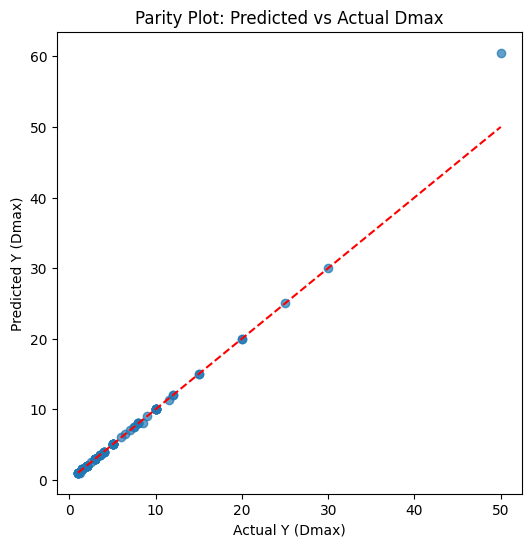

In [74]:
#evaluate the Ghorbani dataset with the best parameters on the test set and print the test RMSE
#split the train data into a train and validation set using an 80/20 split and a fixed random state for reproducibility
Ghorbani_X_train, Ghorbani_X_val, y_train, y_val = train_test_split(Ghorbani_X_train_opt.drop(columns=["Composition String"]), y_train_opt.drop(columns=["Composition String"]), test_size=0.2, random_state=42)

# Train XGBoost regressor with best parameters on the entire train_opt set
model = xgb.XGBRegressor(
    n_estimators=best_parameters_ghorbani['n_estimators'],
    max_depth=best_parameters_ghorbani['max_depth'],
    learning_rate=best_parameters_ghorbani['learning_rate'],
    subsample=best_parameters_ghorbani['subsample'],
    colsample_bytree=best_parameters_ghorbani['colsample_bytree'],
    min_child_weight=best_parameters_ghorbani['min_child_weight'],
    gamma=best_parameters_ghorbani['gamma'],
    reg_alpha=best_parameters_ghorbani['reg_alpha'],
    reg_lambda=best_parameters_ghorbani['reg_lambda'],
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    device='cuda',
    random_state=42
    )

#train the model on the entire train_opt set
model.fit(Ghorbani_X_train, y_train, eval_set=[(Ghorbani_X_val, y_val)], verbose=False)

# Predict and evaluate target RMSE on the test set
dtest = xgb.DMatrix(Ghorbani_X_test.drop(columns=["Composition String"]))
y_pred = model.get_booster().predict(dtest)
test_rmse = np.sqrt(mean_squared_error(y_test.drop(columns=["Composition String"]), y_pred))
print(f"Test RMSE on Ghorbani dataset with optimized parameters: {test_rmse:.4f}")
#create a paridy plot of the predicted vs actual values for the test set
plt.figure(figsize=(6,6))
plt.scatter(y_test.drop(columns=["Composition String"]), y_pred, alpha=0.7)
plt.plot([y_test.drop(columns=["Composition String"]).min(), y_test.drop(columns=["Composition String"]).max()], [y_test.drop(columns=["Composition String"]).min(), y_test.drop(columns=["Composition String"]).max()], 'r--')
plt.xlabel("Actual Y (Dmax)")
plt.ylabel("Predicted Y (Dmax)")
plt.title("Parity Plot: Predicted vs Actual Dmax")
plt.show()

In [61]:
#establish the XGB Evaluate parameters for ax optimization of Peng dataset
def xgb_evaluate_parameters_Peng(parameters):
    
    #unpack parameters
    n_estimators = parameters['n_estimators']
    max_depth = parameters['max_depth']
    learning_rate = parameters['learning_rate']
    subsample = parameters['subsample']
    colsample_bytree = parameters['colsample_bytree']
    minchild_weight = parameters['min_child_weight']
    gamma = parameters['gamma']
    reg_alpha = parameters['reg_alpha']
    reg_lambda = parameters['reg_lambda']
    
    #copy the Peng dataset to avoid modifying the original data
    Peng_X_train_opt_copy = Peng_X_train_opt.copy()

    
    #preform the CV folding using the cv groups created earlier and train an XGBoost model on each fold, then evaluate the RMSE for target prediction on the test set and return the mean and standard error of the RMSEs across the folds    
    fold_rmses = []
    for fold in range(5):
        print(f"Processing fold {fold+1}/5...")
        #create the train and validation sets for this fold
        X_train = Peng_X_train_opt_copy[cv_groups != fold].drop(columns=["Composition String"]).reset_index(drop=True)
        y_train = y_train_opt[cv_groups != fold].drop(columns=["Composition String"]).reset_index(drop=True)
        
        #create the validation set for this fold by splitting the xtrain and ytrain for this fold into a train and validation set using an 80/20 split and a fixed random state for reproducibility
        X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        
        #create the test set for this fold by filtering the Peng_X_test and y_test for the appropriate compositions and dropping the composition string column
        X_test= Peng_X_train_opt_copy[cv_groups == fold].drop(columns=["Composition String"]).reset_index(drop=True)
        y_test = y_train_opt[cv_groups == fold].drop(columns=["Composition String"]).reset_index(drop=True)
        


        # Train XGBoost regressor for target volatility prediction
        model = xgb.XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=minchild_weight,
            gamma=gamma,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            objective='reg:squarederror',
            eval_metric='rmse',
            tree_method='hist',
            device='cuda',
            random_state=42
        )
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

        # Predict and evaluate target RMSE — use DMatrix to keep data on GPU
        dtest = xgb.DMatrix(X_test)
        y_pred = model.get_booster().predict(dtest)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_rmses.append(rmse)
    
    mean_rmse = np.mean(fold_rmses)
    sem_rmse = sem(fold_rmses)
    return mean_rmse, sem_rmse



In [62]:
#establish the ax client and define the search space for the XGBoost hyperparameters to optimize for the Peng dataset
#initiate the ax client and define the parameters to optimize
ax_XGB_Peng_client = Client()

ax_XGB_Peng_client.configure_experiment(
    name="XGB_Peng_optimization",
    parameters = [
        RangeParameterConfig(name="n_estimators", parameter_type="int", bounds=(10, 5000)),
        RangeParameterConfig(name="max_depth", parameter_type="int", bounds=(3, 50)),
        RangeParameterConfig(name="learning_rate", parameter_type="float", bounds=(0.005, 0.2)),
        RangeParameterConfig(name="subsample", parameter_type="float", bounds=(0.5, 1.0)),
        RangeParameterConfig(name="colsample_bytree", parameter_type="float", bounds=(0.5, 1.0)),
        RangeParameterConfig(name="min_child_weight", parameter_type="int", bounds=(1, 10)),
        RangeParameterConfig(name="gamma", parameter_type="float", bounds=(0.0, 5.0)),
        RangeParameterConfig(name="reg_alpha", parameter_type="float", bounds=(1e-8, 10.0)),
        RangeParameterConfig(name="reg_lambda", parameter_type="float", bounds=(1e-3, 1.0))
    ]
)

ax_XGB_Peng_client.configure_optimization(objective = "-mean_rmse")

#establish the save path for the ax client and save the client after each trial to ensure that the optimization process can be resumed in case of any interruptions
ax_XGB_Peng_save_path = r"Ax_checkpoints\Paper_Comparison\XGB_Peng_optimization.json"

In [63]:
# run 100 trials of the optimization with saving
try:
    ax_XGB_Peng_client.load_from_json_file(ax_XGB_Peng_save_path)
    print("Loaded existing Ax client state from checkpoint.")
    completed_trials = len(ax_XGB_Peng_client.summarize())
    remaining_trials = 100 - completed_trials
    print(f"Resuming optimization: {completed_trials} trials completed, {remaining_trials} remaining.")
    
    for n in range(remaining_trials):
        trial_index, parameters = next(
            iter(ax_XGB_Peng_client.get_next_trials(max_trials=1).items())
        )
        print(f"======== Beginning trial {completed_trials + n + 1} of 100 with parameters: {parameters} ========")

        mean_rmse, sem_rmse = xgb_evaluate_parameters_Peng(parameters)
        ax_XGB_Peng_client.complete_trial(trial_index=trial_index, raw_data={"mean_rmse": (mean_rmse, sem_rmse)})
        print(f"Completed trial {completed_trials + n + 1} with parameters: {parameters} and mean_rmse: {mean_rmse:.4f} ± {sem_rmse:.4f}")
        ax_XGB_Peng_client.save_to_json_file(ax_XGB_Peng_save_path)

except FileNotFoundError:
    print("No existing checkpoint found. Starting new optimization.")
    remaining_trials = 100
    for n in range(remaining_trials):
        
        trial_index, parameters = next(
            iter(ax_XGB_Peng_client.get_next_trials(max_trials=1).items())
        )
        print(f"======== Beginning trial {n + 1} of 100 with parameters: {parameters} ========")
        mean_rmse, sem_rmse = xgb_evaluate_parameters_Peng(parameters)
        ax_XGB_Peng_client.complete_trial(trial_index=trial_index, raw_data={"mean_rmse": (mean_rmse, sem_rmse)})
        print(f"Completed trial {n + 1} with parameters: {parameters} and mean_rmse: {mean_rmse:.4f} ± {sem_rmse:.4f}")
        ax_XGB_Peng_client.save_to_json_file(ax_XGB_Peng_save_path)

[INFO 04-15 21:57:04] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol'), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, model_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, model_key_override=None)], transition_criteria=[])]) chosen based on user input and problem structure.
[INFO 04-15 21:57:04] ax.api.client: Generated new trial 0 with parameters {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.1025, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.0, 'reg_lambda': 0.5005} using GenerationNode CenterOfSearchSpace.


No existing checkpoint found. Starting new optimization.
======== Beginning trial 1 of 100 with parameters: {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.10250000000000001, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.000000005, 'reg_lambda': 0.5005} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-15 22:02:07] ax.api.client: Trial 0 marked COMPLETED.
[INFO 04-15 22:02:07] ax.api.client: Generated new trial 1 with parameters {'n_estimators': 4760, 'max_depth': 37, 'learning_rate': 0.069128, 'subsample': 0.798321, 'colsample_bytree': 0.925198, 'min_child_weight': 7, 'gamma': 4.983417, 'reg_alpha': 3.27275, 'reg_lambda': 0.666403} using GenerationNode Sobol.


Completed trial 1 with parameters: {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.10250000000000001, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.000000005, 'reg_lambda': 0.5005} and mean_rmse: 5.7476 ± 0.6844
======== Beginning trial 2 of 100 with parameters: {'n_estimators': 4760, 'max_depth': 37, 'learning_rate': 0.06912842929363251, 'subsample': 0.7983207404613495, 'colsample_bytree': 0.9251982867717743, 'min_child_weight': 7, 'gamma': 4.983416795730591, 'reg_alpha': 3.272750086359055, 'reg_lambda': 0.6664027235507965} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-15 22:05:06] ax.api.client: Trial 1 marked COMPLETED.
[INFO 04-15 22:05:07] ax.api.client: Generated new trial 2 with parameters {'n_estimators': 2026, 'max_depth': 6, 'learning_rate': 0.120127, 'subsample': 0.72324, 'colsample_bytree': 0.687513, 'min_child_weight': 2, 'gamma': 1.715776, 'reg_alpha': 8.405939, 'reg_lambda': 0.301193} using GenerationNode Sobol.


...

Completed trial 99 with parameters: {'n_estimators': 5000, 'max_depth': 50, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 0.5, 'min_child_weight': 1, 'gamma': 5.0, 'reg_alpha': 10.0, 'reg_lambda': 1.0} and mean_rmse: 5.2892 ± 0.7154


[INFO 04-16 00:24:11] ax.api.client: Generated new trial 99 with parameters {'n_estimators': 10, 'max_depth': 50, 'learning_rate': 0.005, 'subsample': 1.0, 'colsample_bytree': 0.5, 'min_child_weight': 1, 'gamma': 0.0, 'reg_alpha': 10.0, 'reg_lambda': 0.001} using GenerationNode MBM.


======== Beginning trial 100 of 100 with parameters: {'n_estimators': 10, 'max_depth': 50, 'learning_rate': 0.005, 'subsample': 1.0, 'colsample_bytree': 0.5, 'min_child_weight': 1, 'gamma': 0.0, 'reg_alpha': 10.0, 'reg_lambda': 0.001} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...


[INFO 04-16 00:24:12] ax.api.client: Trial 99 marked COMPLETED.


Processing fold 5/5...
Completed trial 100 with parameters: {'n_estimators': 10, 'max_depth': 50, 'learning_rate': 0.005, 'subsample': 1.0, 'colsample_bytree': 0.5, 'min_child_weight': 1, 'gamma': 0.0, 'reg_alpha': 10.0, 'reg_lambda': 0.001} and mean_rmse: 5.6128 ± 0.6833


In [64]:
#load the saved optimization results and print the best parameters and corresponding rmse
ax_XGB_Peng_client.load_from_json_file(ax_XGB_Peng_save_path)
best_parameters_peng, best_values_peng, _,_ = ax_XGB_Peng_client.get_best_parameterization()
print(f"Best parameters: {best_parameters_peng}")
print(f"Best mean_rmse: {best_values_peng['mean_rmse'][0]:.4f} ± {best_values_peng['mean_rmse'][1]:.4f}")



Best parameters: {'n_estimators': 397, 'max_depth': 50, 'learning_rate': 0.09188125198179099, 'subsample': 1.0, 'colsample_bytree': 0.5, 'min_child_weight': 10, 'gamma': 5.0, 'reg_alpha': 10.0, 'reg_lambda': 0.8748037131376153}
Best mean_rmse: 5.3622 ± 0.0248


In [65]:
#establish the XGB Evaluate parameters for ax optimization of Xiong dataset
def xgb_evaluate_parameters_Xiong(parameters):
    
    #unpack parameters
    n_estimators = parameters['n_estimators']
    max_depth = parameters['max_depth']
    learning_rate = parameters['learning_rate']
    subsample = parameters['subsample']
    colsample_bytree = parameters['colsample_bytree']
    minchild_weight = parameters['min_child_weight']
    gamma = parameters['gamma']
    reg_alpha = parameters['reg_alpha']
    reg_lambda = parameters['reg_lambda']
    
    #copy the Xiong dataset to avoid modifying the original data
    Xiong_X_train_opt_copy = Xiong_X_train_opt.copy()

    
    #preform the CV folding using the cv groups created earlier and train an XGBoost model on each fold, then evaluate the RMSE for target prediction on the test set and return the mean and standard error of the RMSEs across the folds    
    fold_rmses = []
    for fold in range(5):
        print(f"Processing fold {fold+1}/5...")
        #create the train and validation sets for this fold
        X_train = Xiong_X_train_opt_copy[cv_groups != fold].drop(columns=["Composition String"]).reset_index(drop=True)
        y_train = y_train_opt[cv_groups != fold].drop(columns=["Composition String"]).reset_index(drop=True)
        
        #create the validation set for this fold by splitting the xtrain and ytrain for this fold into a train and validation set using an 80/20 split and a fixed random state for reproducibility
        X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        
        #create the test set for this fold by filtering the Xiong_X_test and y_test for the appropriate compositions and dropping the composition string column
        X_test= Xiong_X_train_opt_copy[cv_groups == fold].drop(columns=["Composition String"]).reset_index(drop=True)
        y_test = y_train_opt[cv_groups == fold].drop(columns=["Composition String"]).reset_index(drop=True)
        


        # Train XGBoost regressor for target volatility prediction
        model = xgb.XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=minchild_weight,
            gamma=gamma,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            objective='reg:squarederror',
            eval_metric='rmse',
            tree_method='hist',
            device='cuda',
            random_state=42
        )
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

        # Predict and evaluate target RMSE — use DMatrix to keep data on GPU
        dtest = xgb.DMatrix(X_test)
        y_pred = model.get_booster().predict(dtest)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_rmses.append(rmse)
    
    mean_rmse = np.mean(fold_rmses)
    sem_rmse = sem(fold_rmses)
    return mean_rmse, sem_rmse



In [66]:
#establish the ax client and define the search space for the XGBoost hyperparameters to optimize for the Xiong dataset
#initiate the ax client and define the parameters to optimize
ax_XGB_Xiong_client = Client()

ax_XGB_Xiong_client.configure_experiment(
    name="XGB_Xiong_optimization",
    parameters = [
        RangeParameterConfig(name="n_estimators", parameter_type="int", bounds=(10, 5000)),
        RangeParameterConfig(name="max_depth", parameter_type="int", bounds=(3, 50)),
        RangeParameterConfig(name="learning_rate", parameter_type="float", bounds=(0.005, 0.2)),
        RangeParameterConfig(name="subsample", parameter_type="float", bounds=(0.5, 1.0)),
        RangeParameterConfig(name="colsample_bytree", parameter_type="float", bounds=(0.5, 1.0)),
        RangeParameterConfig(name="min_child_weight", parameter_type="int", bounds=(1, 10)),
        RangeParameterConfig(name="gamma", parameter_type="float", bounds=(0.0, 5.0)),
        RangeParameterConfig(name="reg_alpha", parameter_type="float", bounds=(1e-8, 10.0)),
        RangeParameterConfig(name="reg_lambda", parameter_type="float", bounds=(1e-3, 1.0))
    ]
)

ax_XGB_Xiong_client.configure_optimization(objective = "-mean_rmse")

#establish the save path for the ax client and save the client after each trial to ensure that the optimization process can be resumed in case of any interruptions
ax_XGB_Xiong_save_path = r"Ax_checkpoints\Paper_Comparison\XGB_Xiong_optimization.json"

In [67]:
# run 100 trials of the optimization with saving
try:
    ax_XGB_Xiong_client.load_from_json_file(ax_XGB_Xiong_save_path)
    print("Loaded existing Ax client state from checkpoint.")
    completed_trials = len(ax_XGB_Xiong_client.summarize())
    remaining_trials = 100 - completed_trials
    print(f"Resuming optimization: {completed_trials} trials completed, {remaining_trials} remaining.")
    
    for n in range(remaining_trials):
        trial_index, parameters = next(
            iter(ax_XGB_Xiong_client.get_next_trials(max_trials=1).items())
        )
        print(f"======== Beginning trial {completed_trials + n + 1} of 100 with parameters: {parameters} ========")

        mean_rmse, sem_rmse = xgb_evaluate_parameters_Xiong(parameters)
        ax_XGB_Xiong_client.complete_trial(trial_index=trial_index, raw_data={"mean_rmse": (mean_rmse, sem_rmse)})
        print(f"Completed trial {completed_trials + n + 1} with parameters: {parameters} and mean_rmse: {mean_rmse:.4f} ± {sem_rmse:.4f}")
        ax_XGB_Xiong_client.save_to_json_file(ax_XGB_Xiong_save_path)

except FileNotFoundError:
    print("No existing checkpoint found. Starting new optimization.")
    remaining_trials = 100
    for n in range(remaining_trials):
        
        trial_index, parameters = next(
            iter(ax_XGB_Xiong_client.get_next_trials(max_trials=1).items())
        )
        print(f"======== Beginning trial {n + 1} of 100 with parameters: {parameters} ========")
        mean_rmse, sem_rmse = xgb_evaluate_parameters_Xiong(parameters)
        ax_XGB_Xiong_client.complete_trial(trial_index=trial_index, raw_data={"mean_rmse": (mean_rmse, sem_rmse)})
        print(f"Completed trial {n + 1} with parameters: {parameters} and mean_rmse: {mean_rmse:.4f} ± {sem_rmse:.4f}")
        ax_XGB_Xiong_client.save_to_json_file(ax_XGB_Xiong_save_path)

[INFO 04-16 00:24:18] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol'), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, model_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, model_key_override=None)], transition_criteria=[])]) chosen based on user input and problem structure.
[INFO 04-16 00:24:18] ax.api.client: Generated new trial 0 with parameters {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.1025, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.0, 'reg_lambda': 0.5005} using GenerationNode CenterOfSearchSpace.


No existing checkpoint found. Starting new optimization.
======== Beginning trial 1 of 100 with parameters: {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.10250000000000001, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.000000005, 'reg_lambda': 0.5005} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-16 00:25:22] ax.api.client: Trial 0 marked COMPLETED.
[INFO 04-16 00:25:22] ax.api.client: Generated new trial 1 with parameters {'n_estimators': 1823, 'max_depth': 13, 'learning_rate': 0.115678, 'subsample': 0.708638, 'colsample_bytree': 0.817185, 'min_child_weight': 9, 'gamma': 0.35156, 'reg_alpha': 7.892016, 'reg_lambda': 0.926012} using GenerationNode Sobol.


Completed trial 1 with parameters: {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.10250000000000001, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.000000005, 'reg_lambda': 0.5005} and mean_rmse: 5.1389 ± 0.7927
======== Beginning trial 2 of 100 with parameters: {'n_estimators': 1823, 'max_depth': 13, 'learning_rate': 0.11567839920520784, 'subsample': 0.7086384147405624, 'colsample_bytree': 0.8171845972537994, 'min_child_weight': 9, 'gamma': 0.351560078561306, 'reg_alpha': 7.892016174517041, 'reg_lambda': 0.9260117149353028} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-16 00:26:15] ax.api.client: Trial 1 marked COMPLETED.
[INFO 04-16 00:26:15] ax.api.client: Generated new trial 2 with parameters {'n_estimators': 3945, 'max_depth': 47, 'learning_rate': 0.033323, 'subsample': 0.91395, 'colsample_bytree': 0.578707, 'min_child_weight': 2, 'gamma': 3.830595, 'reg_alpha': 0.560218, 'reg_lambda': 0.217617} using GenerationNode Sobol.


...

Completed trial 99 with parameters: {'n_estimators': 3028, 'max_depth': 50, 'learning_rate': 0.11536379081524394, 'subsample': 0.5, 'colsample_bytree': 1.0, 'min_child_weight': 10, 'gamma': 0.0, 'reg_alpha': 4.322073080124874, 'reg_lambda': 0.6327646647080787} and mean_rmse: 5.3002 ± 0.8007


[INFO 04-16 02:34:24] ax.api.client: Generated new trial 99 with parameters {'n_estimators': 4672, 'max_depth': 15, 'learning_rate': 0.125401, 'subsample': 0.5, 'colsample_bytree': 0.524685, 'min_child_weight': 10, 'gamma': 3.364366, 'reg_alpha': 10.0, 'reg_lambda': 0.001} using GenerationNode MBM.


======== Beginning trial 100 of 100 with parameters: {'n_estimators': 4672, 'max_depth': 15, 'learning_rate': 0.12540087602601216, 'subsample': 0.5, 'colsample_bytree': 0.5246852985443656, 'min_child_weight': 10, 'gamma': 3.3643662470822684, 'reg_alpha': 10.0, 'reg_lambda': 0.001} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-16 02:35:52] ax.api.client: Trial 99 marked COMPLETED.


Completed trial 100 with parameters: {'n_estimators': 4672, 'max_depth': 15, 'learning_rate': 0.12540087602601216, 'subsample': 0.5, 'colsample_bytree': 0.5246852985443656, 'min_child_weight': 10, 'gamma': 3.3643662470822684, 'reg_alpha': 10.0, 'reg_lambda': 0.001} and mean_rmse: 4.9946 ± 0.8695


In [68]:
#load the saved optimization results and print the best parameters and corresponding rmse
ax_XGB_Xiong_client.load_from_json_file(ax_XGB_Xiong_save_path)
best_parameters_Xiong, best_values_Xiong, _,_ = ax_XGB_Xiong_client.get_best_parameterization()
print(f"Best parameters: {best_parameters_Xiong}")
print(f"Best mean_rmse: {best_values_Xiong['mean_rmse'][0]:.4f} ± {best_values_Xiong['mean_rmse'][1]:.4f}")



Best parameters: {'n_estimators': 550, 'max_depth': 20, 'learning_rate': 0.005, 'subsample': 0.5, 'colsample_bytree': 0.6739013044359725, 'min_child_weight': 10, 'gamma': 0.0, 'reg_alpha': 10.0, 'reg_lambda': 0.4852648042961053}
Best mean_rmse: 5.0880 ± 0.0305


In [69]:
# create the evaluate parameters for the CBFV and CALPHAD features using the same CV folds and XGBoost model training and evaluation process as the other datasets for a fair comparison of model performance on the same compositions

def xgb_evaluate_parameters_Norman(parameters):
        
    #unpack parameters
    n_estimators = parameters['n_estimators']
    max_depth = parameters['max_depth']
    learning_rate = parameters['learning_rate']
    subsample = parameters['subsample']
    colsample_bytree = parameters['colsample_bytree']
    minchild_weight = parameters['min_child_weight']
    gamma = parameters['gamma']
    reg_alpha = parameters['reg_alpha']
    reg_lambda = parameters['reg_lambda']
    
    #copy the Norman dataset to avoid modifying the original data
    Norman_X_train_opt_copy = Norman_X_train_opt.copy()

    
    #preform the CV folding using the cv groups created earlier and train an XGBoost model on each fold, then evaluate the RMSE for target prediction on the test set and return the mean and standard error of the RMSEs across the folds    
    fold_rmses = []
    for fold in range(5):
        print(f"Processing fold {fold+1}/5...")
        #create the train and validation sets for this fold
        X_train = Norman_X_train_opt_copy[cv_groups != fold].drop(columns=["alloy_string"]).reset_index(drop=True)
        y_train = y_train_opt[cv_groups != fold].drop(columns=["Composition String"]).reset_index(drop=True)
        
        #create the validation set for this fold by splitting the xtrain and ytrain for this fold into a train and validation set using an 80/20 split and a fixed random state for reproducibility
        X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        
        #create the test set for this fold by filtering the Norman_X_train_opt_copy and y_train_opt for the appropriate compositions and dropping the composition string column
        X_test= Norman_X_train_opt_copy[cv_groups == fold].drop(columns=["alloy_string"]).reset_index(drop=True)
        y_test = y_train_opt[cv_groups == fold].drop(columns=["Composition String"]).reset_index(drop=True)
        


        # Train XGBoost regressor for target volatility prediction
        model = xgb.XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=minchild_weight,
            gamma=gamma,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            objective='reg:squarederror',
            eval_metric='rmse',
            tree_method='hist',
            device='cuda',
            random_state=42
        )
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

        # Predict and evaluate target RMSE — use DMatrix to keep data on GPU
        dtest = xgb.DMatrix(X_test)
        y_pred = model.get_booster().predict(dtest)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_rmses.append(rmse)
    
    mean_rmse = np.mean(fold_rmses)
    sem_rmse = sem(fold_rmses)
    return mean_rmse, sem_rmse

In [70]:
#initate the ax client and save path for the Norman dataset optimization
ax_XGB_Norman_client = Client()

ax_XGB_Norman_client.configure_experiment(
    name="XGB_Norman_optimization",
    parameters = [
        RangeParameterConfig(name="n_estimators", parameter_type="int", bounds=(10, 5000)),
        RangeParameterConfig(name="max_depth", parameter_type="int", bounds=(3, 50)),
        RangeParameterConfig(name="learning_rate", parameter_type="float", bounds=(0.005, 0.2)),
        RangeParameterConfig(name="subsample", parameter_type="float", bounds=(0.5, 1.0)),
        RangeParameterConfig(name="colsample_bytree", parameter_type="float", bounds=(0.5, 1.0)),
        RangeParameterConfig(name="min_child_weight", parameter_type="int", bounds=(1, 10)),
        RangeParameterConfig(name="gamma", parameter_type="float", bounds=(0.0, 5.0)),
        RangeParameterConfig(name="reg_alpha", parameter_type="float", bounds=(1e-8, 10.0)),
        RangeParameterConfig(name="reg_lambda", parameter_type="float", bounds=(1e-3, 1.0))
    ]
)

ax_XGB_Norman_client.configure_optimization(objective = "-mean_rmse")

#establish the save path for the ax client and save the client after each trial to ensure that the optimization process can be resumed in case of any interruptions
ax_XGB_Norman_save_path = r"Ax_checkpoints\Paper_Comparison\XGB_Norman_optimization.json"

In [71]:
#perform the optimization with saving after each trial
try:
    ax_XGB_Norman_client.load_from_json_file(ax_XGB_Norman_save_path)
    print("Loaded existing Ax client state from checkpoint.")
    completed_trials = len(ax_XGB_Norman_client.summarize())
    remaining_trials = 100 - completed_trials
    print(f"Resuming optimization: {completed_trials} trials completed, {remaining_trials} remaining.")
    
    for n in range(remaining_trials):
        trial_index, parameters = next(
            iter(ax_XGB_Norman_client.get_next_trials(max_trials=1).items())
        )
        print(f"======== Beginning trial {completed_trials + n + 1} of 100 with parameters: {parameters} ========")

        mean_rmse, sem_rmse = xgb_evaluate_parameters_Norman(parameters)
        ax_XGB_Norman_client.complete_trial(trial_index=trial_index, raw_data={"mean_rmse": (mean_rmse, sem_rmse)})
        print(f"Completed trial {completed_trials + n + 1} with parameters: {parameters} and mean_rmse: {mean_rmse:.4f} ± {sem_rmse:.4f}")
        ax_XGB_Norman_client.save_to_json_file(ax_XGB_Norman_save_path)

except FileNotFoundError:
    print("No existing checkpoint found. Starting new optimization.")
    remaining_trials = 100
    for n in range(remaining_trials):
        
        trial_index, parameters = next(
            iter(ax_XGB_Norman_client.get_next_trials(max_trials=1).items())
        )
        print(f"======== Beginning trial {n + 1} of 100 with parameters: {parameters} ========")
        mean_rmse, sem_rmse = xgb_evaluate_parameters_Norman(parameters)
        ax_XGB_Norman_client.complete_trial(trial_index=trial_index, raw_data={"mean_rmse": (mean_rmse, sem_rmse)})
        print(f"Completed trial {n + 1} with parameters: {parameters} and mean_rmse: {mean_rmse:.4f} ± {sem_rmse:.4f}")
        ax_XGB_Norman_client.save_to_json_file(ax_XGB_Norman_save_path)

[INFO 04-16 02:35:57] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol'), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, model_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, model_key_override=None)], transition_criteria=[])]) chosen based on user input and problem structure.
[INFO 04-16 02:35:57] ax.api.client: Generated new trial 0 with parameters {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.1025, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.0, 'reg_lambda': 0.5005} using GenerationNode CenterOfSearchSpace.


No existing checkpoint found. Starting new optimization.
======== Beginning trial 1 of 100 with parameters: {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.10250000000000001, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.000000005, 'reg_lambda': 0.5005} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-16 02:41:50] ax.api.client: Trial 0 marked COMPLETED.
[INFO 04-16 02:41:51] ax.api.client: Generated new trial 1 with parameters {'n_estimators': 1227, 'max_depth': 6, 'learning_rate': 0.113245, 'subsample': 0.753579, 'colsample_bytree': 0.678952, 'min_child_weight': 3, 'gamma': 1.228076, 'reg_alpha': 4.706845, 'reg_lambda': 0.470524} using GenerationNode Sobol.


Completed trial 1 with parameters: {'n_estimators': 2505, 'max_depth': 26, 'learning_rate': 0.10250000000000001, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_weight': 5, 'gamma': 2.5, 'reg_alpha': 5.000000005, 'reg_lambda': 0.5005} and mean_rmse: 6.5046 ± 0.5916
======== Beginning trial 2 of 100 with parameters: {'n_estimators': 1227, 'max_depth': 6, 'learning_rate': 0.11324477195739747, 'subsample': 0.7535794675350189, 'colsample_bytree': 0.6789519488811493, 'min_child_weight': 3, 'gamma': 1.228075698018074, 'reg_alpha': 4.706845288801455, 'reg_lambda': 0.47052413362264633} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-16 02:44:24] ax.api.client: Trial 1 marked COMPLETED.
[INFO 04-16 02:44:24] ax.api.client: Generated new trial 2 with parameters {'n_estimators': 2735, 'max_depth': 27, 'learning_rate': 0.083925, 'subsample': 0.54602, 'colsample_bytree': 0.770067, 'min_child_weight': 9, 'gamma': 4.378342, 'reg_alpha': 6.268733, 'reg_lambda': 0.70065} using GenerationNode Sobol.


...

Completed trial 99 with parameters: {'n_estimators': 10, 'max_depth': 50, 'learning_rate': 0.005, 'subsample': 0.5, 'colsample_bytree': 1.0, 'min_child_weight': 10, 'gamma': 5.0, 'reg_alpha': 10.0, 'reg_lambda': 0.001} and mean_rmse: 5.6408 ± 0.6837


[INFO 04-16 05:58:16] ax.api.client: Generated new trial 99 with parameters {'n_estimators': 604, 'max_depth': 50, 'learning_rate': 0.005, 'subsample': 1.0, 'colsample_bytree': 0.5, 'min_child_weight': 10, 'gamma': 5.0, 'reg_alpha': 10.0, 'reg_lambda': 1.0} using GenerationNode MBM.


======== Beginning trial 100 of 100 with parameters: {'n_estimators': 604, 'max_depth': 50, 'learning_rate': 0.005, 'subsample': 1.0, 'colsample_bytree': 0.5, 'min_child_weight': 10, 'gamma': 5.0, 'reg_alpha': 10.0, 'reg_lambda': 1.0} ========
Processing fold 1/5...
Processing fold 2/5...
Processing fold 3/5...
Processing fold 4/5...
Processing fold 5/5...


[INFO 04-16 06:00:00] ax.api.client: Trial 99 marked COMPLETED.


Completed trial 100 with parameters: {'n_estimators': 604, 'max_depth': 50, 'learning_rate': 0.005, 'subsample': 1.0, 'colsample_bytree': 0.5, 'min_child_weight': 10, 'gamma': 5.0, 'reg_alpha': 10.0, 'reg_lambda': 1.0} and mean_rmse: 5.8548 ± 0.6885


In [72]:
#load the saved optimization results and print the best parameters and corresponding rmse
ax_XGB_Norman_client.load_from_json_file(ax_XGB_Norman_save_path)
best_parameters_Norman, best_values_Norman, _,_ = ax_XGB_Norman_client.get_best_parameterization()
print(f"Best parameters: {best_parameters_Norman}")
print(f"Best mean_rmse: {best_values_Norman['mean_rmse'][0]:.4f} ± {best_values_Norman['mean_rmse'][1]:.4f}")



Best parameters: {'n_estimators': 10, 'max_depth': 3, 'learning_rate': 0.005, 'subsample': 0.5015505132398679, 'colsample_bytree': 0.5, 'min_child_weight': 10, 'gamma': 5.0, 'reg_alpha': 10.0, 'reg_lambda': 0.001}
Best mean_rmse: 5.6586 ± 0.0260
